In [20]:
import numpy as np
import numpy_financial as npf
import pandas as pd

cashflows1 = np.array([-100, 30, 30, 30, 30, 30])
cashflows2 = np.array([-150, 42, 42, 42, 42, 42])

print(f"IRR1:{npf.irr(cashflows1)}")
print(f"IRR2:{npf.irr(cashflows2)}")
print(f"PV1(5%):{npf.npv(0.05, cashflows1)}")
print(f"PV2(5%):{npf.npv(0.05, cashflows2)}")

IRR1:0.1523823711663066
IRR2:0.12376241456867554
PV1(5%):29.88430011892456
PV2(5%):31.838020166494395


In [9]:
incremental_cf = cashflows1 - cashflows2
print(npf.irr(incremental_cf))

0.06402240764310085


In [10]:
irr = npf.irr(incremental_cf)
d = 1 / (1 + irr)
print(d)

0.9398298314178215


In [18]:
initial_investment = 10000
tax_rate = 0.45
r = 0.10

def dep1(initial_investment):
    return np.array([0, initial_investment*0.25, initial_investment*0.38, initial_investment*0.37])
def dep2(initial_investment):
    return np.array([0, initial_investment/3, initial_investment/3, initial_investment/3])

shield1 = dep1(initial_investment) * tax_rate
shield2 = dep2(initial_investment) * tax_rate

print(f"NPV1({r*100}%):{npf.npv(r, shield1)}")
print(f"NPV2({r*100}%):{npf.npv(r, shield2)}")

NPV1(10.0%):3686.8895567242666
NPV2(10.0%):3730.2779864763324


In [25]:
r_grid = np.linspace(0, 0.3, 31)
tax_grid = np.linspace(0, 0.6, 31)

rows = []
for tax in tax_grid:
    for r in r_grid:
        npv1 = npf.npv(r, dep1(initial_investment) * tax)
        npv2 = npf.npv(r, dep2(initial_investment) * tax)
        diff = npv1 - npv2
        rows.append({"tax_rate": tax, "r": r, "NPV1": npv1, "NPV2": npv2, "NPV1_minus_NPV2": diff})

df = pd.DataFrame(rows)

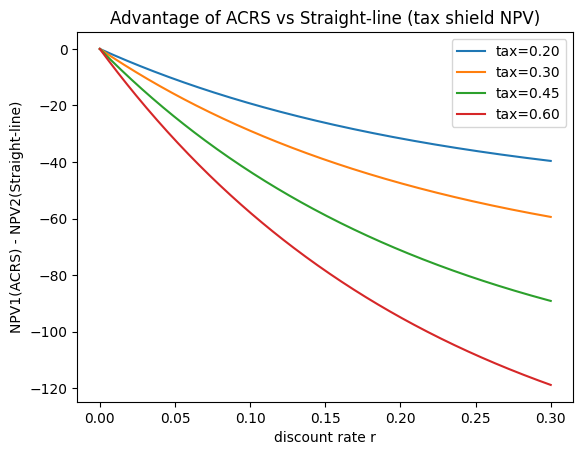

In [27]:
import matplotlib.pyplot as plt

def shield_npv(cost, tax_rate, r, dep_fn):
    shield = dep_fn(cost) * tax_rate
    return npf.npv(r, shield)

r_grid = np.linspace(0.00, 0.30, 301)
tax_list = [0.2, 0.3, 0.45, 0.6]

for tax in tax_list:
    npv1_vals = [shield_npv(initial_investment, tax, r, dep1) for r in r_grid]
    npv2_vals = [shield_npv(initial_investment, tax, r, dep2) for r in r_grid]
    diff_vals = np.array(npv1_vals) -np.array(npv2_vals)
    plt.plot(r_grid, diff_vals, label=f"tax={tax:.2f}")

plt.xlabel("discount rate r")
plt.ylabel("NPV1(ACRS) - NPV2(Straight-line)")
plt.title("Advantage of ACRS vs Straight-line (tax shield NPV)")
plt.legend()
plt.show()

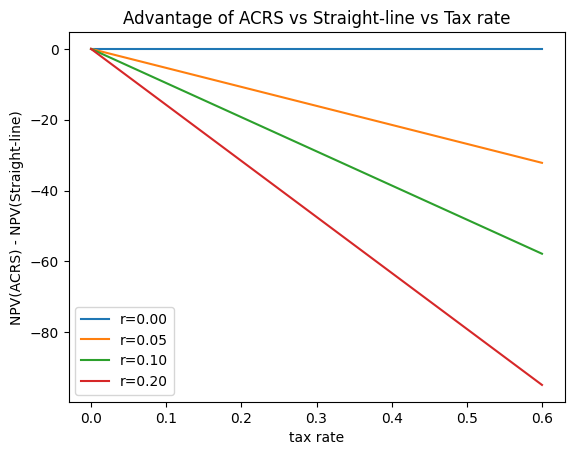

In [29]:
tax_grid = np.linspace(0.00, 0.60, 301)
r_list = [0.0, 0.05, 0.10, 0.20]

def npvs(cost, tax_rate, r):
    npv1 = shield_npv(cost, tax_rate, r, dep1)
    npv2 = shield_npv(cost, tax_rate, r, dep2)
    return npv1, npv2, npv1 - npv2

for r in r_list:
    diff_vals = [npvs(initial_investment, tax, r)[2] for tax in tax_grid]
    plt.plot(tax_grid, diff_vals, label=f"r={r:.2f}")

plt.xlabel("tax rate")
plt.ylabel("NPV(ACRS) - NPV(Straight-line)")
plt.title("Advantage of ACRS vs Straight-line vs Tax rate")
plt.legend()
plt.show()